<a href="https://colab.research.google.com/github/Data-Vitor/fiap-data-science/blob/main/nemec-estatistica/cap06_testes_hipotese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Capítulo 6 - Testes de Hipóteses**


In [1]:
print('Hello, (data)World!')

Hello, (data)World!


In [24]:
!pip install graphviz --quiet

**Calculando o P-valor com o método T-Student**

In [3]:
import numpy as np
from scipy.stats import t

#tamanho da amostra
n = 10
#Valor aevitario para estatistica t
t_stats = 4
#graus de liberdade, que nesse caso e o tamanho da amostra -1
gl =n-1
#calculo do p-valor para um teste bicaudal
p_valor = 2* t.sf(np.abs(t_stats), df=gl)
print(f'p-valor bicaudal: {p_valor:.4f}')

#calculo do p-valor para um teste unicaudal a direita
#teste onde temos o "maior que"
p_valor = t.sf(t_stats, df=gl)
print(f'P-valor unicaudal a direita: {p_valor:.4f}')

#calculo do p-valor para um teste unicaudal a esquerda
#teste inde temos "o menos que"
p_valor = t.cdf(t_stats, df=gl)
print(f'P-valor uncaudal a esquerda: {p_valor:.4f}')



p-valor bicaudal: 0.0031
P-valor unicaudal a direita: 0.0016
P-valor uncaudal a esquerda: 0.9984


**calculando o p-valor utilizando o método T-student PAREADO**

In [10]:
import numpy as np
from scipy.stats import ttest_rel


#dados: produção antes e depois
antes = np.array([20,22,19,24,21])
depois = np.array([24,23,23,25,26])

#teste t pareado
t_stat, p_valor = ttest_rel(depois, antes, alternative='greater')

print(f'Estatistica t: {t_stat:.2f}')
print(f'p-valor: {p_valor:.4f}')


Estatistica t: 3.59
p-valor: 0.0115


***Calculando o Teste T para amostras INDEPENDESTES***

In [13]:
import numpy as np
from scipy.stats import ttest_ind

#dados dos grupos
grupo_a =np.array([24,27,25,26,28])
grupo_b =np.array([22,23,20,21,24])
#teste t independente
t_stat, p_valor = ttest_ind(grupo_a, grupo_b, equal_var=True)

print(f'estatistica: {t_stats:.2f}')
print(f'p-valor: {p_valor:.4f}')


estatistica: 4.00
p-valor: 0.0039


***Calculando o Teste T para UMA AMOSTRA***

In [15]:
import numpy as np
from scipy.stats import ttest_1samp

#dados de produção das vacas
producao =np.array([24,27,25,26,28])

#teste t para uma amostra (meta = 25)
t_stat, p_valor = ttest_1samp(producao, 25, alternative='greater')
print(f'Estatistica t: {t_stat:.2f}')
print(f'p-valor: {p_valor:.4f}')

Estatistica t: 1.41
p-valor: 0.1151


***Descobrindo a normalidade dos dados atravé do teste de Shapiro-Wilk***

In [16]:
import numpy as np
from scipy.stats import shapiro

#se o p-valor for menor que o nivel de significancia, regeitamos H0 e concluimos que os dados **NÃO SAO NORMAIS**
#exemplos de dados
dados = np.array([24,27,25,26,28,24,29,25,26,27])

#teste de shapiro-wilk
stat, p_valor = shapiro(dados)
print(f'estatistica w: {stat:.4f}')
print(f'p=valor: {p_valor:.2f}')

if p_valor <0.05:
  print('Rejeita H0: Os dados não são normais')
else:
  print('Não rejeita H0: Não há evidencia contra a normalidade')

estatistica w: 0.9481
p=valor: 0.65
Não rejeita H0: Não há evidencia contra a normalidade


***Descobrindo a homocedasticidade através do Teste de Levene***

In [17]:
import numpy as np
from scipy.stats import levene

#h0 : amostra são homocedásticas (tem variancias iguais)
#as amostras são heterocedásticas (carecteristica de uma ou mais amostras com variancia estatisticamente diferente)

#dados de exemplo (produção de leite de dois grupos)
grupo_a = np.array([24,27,25,26,28])
grupo_b = np.array([22,23,20,21,24])

#teste de Levene
stat, p_valor =levene(grupo_a, grupo_b)
print(f'Estatistica de levene: {stat:.4f}')
print(f'P-valor {p_valor:.2f}')

if p_valor < 0.05:
  print('Rejeita H0: As variancias são diferentes (heterocedasticidade)')
else:
  print('não rejeita h0: as variancas podem ser conseideradas iguais (homocedasticidade)')

Estatistica de levene: 0.0000
P-valor 1.00
não rejeita h0: as variancas podem ser conseideradas iguais (homocedasticidade)


**Plotando o Violin plot para VISUALMENTE compararmos a variancia de duas amostras**

<function matplotlib.pyplot.show(close=None, block=None)>

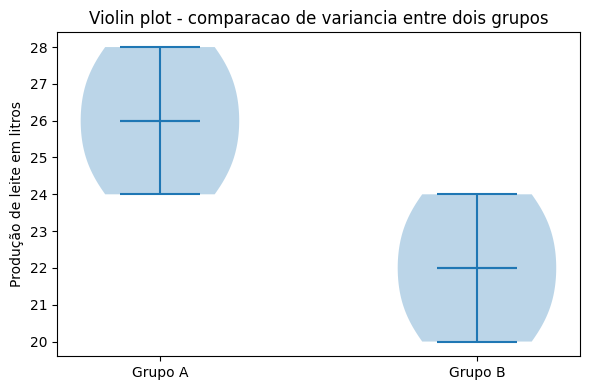

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#dados de exemplo (produção de leite dos dois grupos)
grupo_a = np.array([24,27,25,26,28])
grupo_b = np.array([22,23,20,21,24])

#empacotando para o violinplot
dados = [grupo_a, grupo_b]

plt.figure(figsize=(6,4))
plt.violinplot(dados, showmeans=True, showmedians=True)
plt.xticks([1,2], ['Grupo A', 'Grupo B' ])
plt.ylabel('Produção de leite em litros')
plt.title('Violin plot - comparacao de variancia entre dois grupos')
plt.tight_layout()
plt.show

**Teste de Welch - Variação do Teste T de Studente para AMOSTRAS INDEPENDENTES, quando não podemos assumir a homocedasticidade**

In [23]:
import numpy as np
from scipy.stats import ttest_ind

#Grupos de exemplo com variancias diferentes
grupo_a = np.array([24,27,25,26,28])
grupo_b = np.array([15,22,35,27,40])

#teste de Welche
t_stat, p_valor = ttest_ind(grupo_a, grupo_b, equal_var=False)

print(f'Estatistica T: {stat:.4f}')
print(f'P-valor {p_valor:.2f}')



Estatistica T: 0.0000
P-valor 0.71


**Fluxograma de decisão, testes paramétricos**

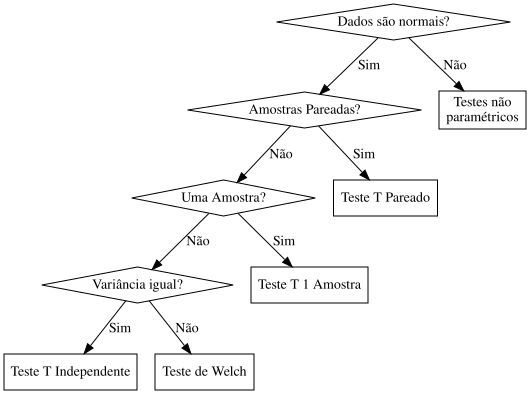

In [25]:
!pip install graphviz --quiet

from graphviz import Digraph

# ==========================================================
# 1) FUNÇÃO DE DECISÃO - segue exatamente o fluxograma
# ==========================================================
def escolher_teste_t(normais, pareadas=None, uma_amostra=None, variancia_igual=None):
    if not normais:
        return "Testes não paramétricos (Mann-Whitney, Wilcoxon...)"
    if pareadas:
        return "Teste T Pareado"
    if uma_amostra:
        return "Teste T 1 Amostra"
    if variancia_igual:
        return "Teste T Independente"
    return "Teste de Welch"

# ==========================================================
# 2) DIAGRAMA VISUAL (Figura 6.7)
# ==========================================================
dot = Digraph(comment='Fluxograma de decisão - Testes T')
dot.attr(rankdir='TB')

# nós de decisão (losangos)
dot.node('A', 'Dados são normais?', shape='diamond')
dot.node('B', 'Amostras Pareadas?', shape='diamond')
dot.node('C', 'Uma Amostra?', shape='diamond')
dot.node('D', 'Variância igual?', shape='diamond')

# nós de resultado (retângulos)
dot.node('R0', 'Testes não\nparamétricos', shape='box')
dot.node('R1', 'Teste T Pareado', shape='box')
dot.node('R2', 'Teste T 1 Amostra', shape='box')
dot.node('R3', 'Teste T Independente', shape='box')
dot.node('R4', 'Teste de Welch', shape='box')

# conexões, seguindo exatamente as setas da figura
dot.edge('A', 'R0', label='Não')
dot.edge('A', 'B', label='Sim')
dot.edge('B', 'R1', label='Sim')
dot.edge('B', 'C', label='Não')
dot.edge('C', 'R2', label='Sim')
dot.edge('C', 'D', label='Não')
dot.edge('D', 'R3', label='Sim')
dot.edge('D', 'R4', label='Não')

dot

**Teste U de mannWhitneyU**

In [29]:
import numpy as np
from scipy.stats import mannwhitneyu


grupoa = np.array([24,27,25,26,28])
grupob = np.array([22,23,20,21,24])

#teste bicaudal
stat, p_valor = mannwhitneyu(grupoa, grupob, alternative='two-sided')

print(f'estatisitca U: {stat:.4f}')
print(f'p-valor: {p_valor:.4f}')

estatisitca U: 24.5000
p-valor: 0.0160


**Teste de Wilconxon Signed-Rank**

In [32]:
import numpy as no
from scipy.stats import wilcoxon

antes = np.array([12,9,15,10,11])
depois = np.array([14,8,15,12,7])

stat, p_valor = wilcoxon(depois, antes)

print(f'estatisitca : {stat}')
print(f'p-valor: {p_valor:.4f}')

estatisitca : 5.0
p-valor: 1.0000


**Cálculo do Teste F (medindo a variancia)**

In [34]:
import pandas as pd
from scipy.stats import f

# Dados simulados de produção diária de leite (em litros)
dados = {
    'antes': [32, 30, 29, 33, 28, 34, 31, 32, 30, 33],
    'depois': [30, 30, 30, 31, 29, 29, 30, 29, 30, 29]
}

df = pd.DataFrame(dados)

# Calculando as variâncias amostrais
var_antes = df['antes'].var(ddof=1)
var_depois = df['depois'].var(ddof=1)

print(f'Variância antes: {var_antes:.2f}')
print(f'Variância depois: {var_depois:.2f}')

# Calculando a estatística F (maior variância no numerador)
if var_antes > var_depois:
    F = var_antes / var_depois
else:
    F = var_depois / var_antes

print(f'Estatística F: {F:.2f}')

# Graus de liberdade
gl1 = len(df['antes']) - 1
gl2 = len(df['depois']) - 1

print(f'Graus de liberdade do numerador: {gl1}')
print(f'Graus de liberdade do denominador: {gl2}')

# Probabilidade da variância maior após o experimento
p_valor_esquerda = f.cdf(F, gl1, gl2)

# Probabilidade da variância menor após o experimento
p_valor_direita = 1 - f.cdf(F, gl1, gl2)

# Calculando o p-valor (bicaudal)
p_valor = 2 * min(p_valor_direita, p_valor_esquerda)

print(f'p-valor: {p_valor:.4f}')
print(f'p-valor unicaudal a esquerda: {p_valor_esquerda:.4f}')
print(f'p-valor unicaudal a direita : {p_valor_direita:.4f}')

Variância antes: 3.73
Variância depois: 0.46
Estatística F: 8.20
Graus de liberdade do numerador: 9
Graus de liberdade do denominador: 9
p-valor: 0.0044
p-valor unicaudal a esquerda: 0.9978
p-valor unicaudal a direita : 0.0022
